In [1]:
import os
import urllib.request
import tarfile
import numpy as np
import cv2 as cv
from PIL import Image
import matplotlib.pyplot as plt
from shutil import copyfile
import csv

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms.functional as TF

# Import za Google Colab
from google.colab import drive

print("PyTorch verzija:", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Koristi se uređaj:", device)

PyTorch verzija: 2.10.0+cu128
Koristi se uređaj: cuda


In [2]:
########################################################################################################################
# 1. PODEŠAVANJA
########################################################################################################################

image_size = 256

batch_size = 32
init_lr = 1e-3
reduce_lr_patience = 5
reduce_lr_factor = 0.1
early_stopping_patience = 3 * reduce_lr_patience
num_epochs = 1000

In [3]:
########################################################################################################################
# 2. MONTIRANJE GOOGLE DRIVE-A I PODEŠAVANJE PUTANJA
########################################################################################################################

drive.mount('/content/drive')

drive_results_folder = '/content/drive/MyDrive/VOC2012_UNet_Results_PyTorch'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

Mounted at /content/drive
Napravljen direktorijum za rezultate na Drive-u: /content/drive/MyDrive/VOC2012_UNet_Results_PyTorch


In [4]:
########################################################################################################################
# 3. PREUZIMANJE I RASPAKIVANJE PODATAKA
########################################################################################################################

dataset_url = "https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"
tar_path = "/content/VOCtrainval_11-May-2012.tar"
data_folder = "/content/VOCdevkit/VOC2012"

if not os.path.exists(tar_path):
    print("Preuzimanje dataseta...")
    urllib.request.urlretrieve(dataset_url, tar_path)
    print("Preuzimanje završeno.")

if not os.path.exists(data_folder):
    print("Raspakivanje dataseta...")
    with tarfile.open(tar_path) as tar_ref:
        tar_ref.extractall('/content/', filter='data')
    print("Podaci su spremni.")

train_folder = os.path.join(data_folder, 'JPEGImages')
train_folder_gt = os.path.join(data_folder, 'SegmentationClass')

train_images_gt = sorted(os.listdir(train_folder_gt))
print('Broj slika:', len(train_images_gt))

Preuzimanje dataseta...
Preuzimanje završeno.
Raspakivanje dataseta...
Podaci su spremni.
Broj slika: 2913


In [5]:
########################################################################################################################
# 4. FUNKCIJE ZA KREIRANJE MODELA
########################################################################################################################

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.0):
        super(ConvBlock, self).__init__()

        self.use_shortcut = in_channels != out_channels
        if self.use_shortcut:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)

        self.dropout = nn.Dropout2d(dropout_rate) if dropout_rate > 0 else nn.Identity()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x):
        shortcut = self.shortcut(x) if self.use_shortcut else x

        y = self.conv1(x)
        y = self.bn1(y)
        y = self.relu1(y)

        y = self.dropout(y)

        y = self.conv2(y)
        y = self.bn2(y)

        return self.relu2(y + shortcut)


class UNetFromScratch(nn.Module):
    def __init__(self, num_classes=21):
        super(UNetFromScratch, self).__init__()

        # ENKODER
        self.enc1 = ConvBlock(3, 32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc4 = ConvBlock(128, 256, dropout_rate=0.3)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # BOTTLENECK (najdublji deo mreže)
        self.bottleneck = ConvBlock(256, 512, dropout_rate=0.5)

        # Alat za podizanje rezolucije (Upsampling)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # DEKODER
        # Napomena: Ulazni kanali u dekoderu su suma (concatenate) izlaza prethodnog sloja i skip konekcije
        self.dec1 = ConvBlock(512 + 256, 256, dropout_rate=0.3)
        self.dec2 = ConvBlock(256 + 128, 128)
        self.dec3 = ConvBlock(128 + 64, 64)
        self.dec4 = ConvBlock(64 + 32, 32)

        # IZLAZNI SLOJ
        self.out_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # Enkoder putanja sa čuvanjem aktivacija za skip connections
        c1 = self.enc1(x)
        p1 = self.pool1(c1)

        c2 = self.enc2(p1)
        p2 = self.pool2(c2)

        c3 = self.enc3(p2)
        p3 = self.pool3(c3)

        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        b = self.bottleneck(p4)

        # Dekoder putanja sa konkatenacijom (skip connections)
        d1 = self.up(b)
        d1 = torch.cat([d1, c4], dim=1) # Spajanje po kanalu (dimenzija 1)
        d1 = self.dec1(d1)

        d2 = self.up(d1)
        d2 = torch.cat([d2, c3], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up(d2)
        d3 = torch.cat([d3, c2], dim=1)
        d3 = self.dec3(d3)

        d4 = self.up(d3)
        d4 = torch.cat([d4, c1], dim=1)
        d4 = self.dec4(d4)

        return self.out_conv(d4)


class MobileNetV2_UNet(nn.Module):
    def __init__(self, num_classes=21):
        super(MobileNetV2_UNet, self).__init__()

        # Učitavanje pre-treniranog MobileNetV2
        # Koristimo weights parametar prema novim torchvision standardima
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        features = mobilenet.features

        # Zamrzavanje težina enkodera
        for param in features.parameters():
            param.requires_grad = False

        # Izdvajanje specifičnih slojeva za skip connections
        self.enc1 = features[0:2]   # 1/2 rezolucija, 16 filtera
        self.enc2 = features[2:4]   # 1/4 rezolucija, 24 filtera
        self.enc3 = features[4:7]   # 1/8 rezolucija, 32 filtera
        self.enc4 = features[7:14]  # 1/16 rezolucija, 96 filtera
        self.bottleneck = features[14:18] # 1/32 rezolucija, 320 filtera

        self.up = nn.Upsample(scale_factor=2, mode='nearest')

        # Dekoder (Ulazni kanali su suma kanala iz upsample + skip konekcije)
        self.dec1 = ConvBlock(320 + 96, 512, dropout_rate=0.3)
        self.dec2 = ConvBlock(512 + 32, 256, dropout_rate=0.3)
        self.dec3 = ConvBlock(256 + 24, 128)
        self.dec4 = ConvBlock(128 + 16, 64)
        self.dec5 = ConvBlock(64, 32)

        # Izlazni sloj (CrossEntropyLoss u PyTorch-u obuhvata Softmax, pa ga izostavljamo ovde)
        self.out_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # Enkoder
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b = self.bottleneck(s4)

        # Dekoder
        d = self.up(b)
        d = torch.cat([d, s4], dim=1)
        d = self.dec1(d)

        d = self.up(d)
        d = torch.cat([d, s3], dim=1)
        d = self.dec2(d)

        d = self.up(d)
        d = torch.cat([d, s2], dim=1)
        d = self.dec3(d)

        d = self.up(d)
        d = torch.cat([d, s1], dim=1)
        d = self.dec4(d)

        d = self.up(d)
        d = self.dec5(d)

        return self.out_conv(d)

In [6]:
########################################################################################################################
# 5. PODRŠKA ZA UČITAVANJE I AUGMENTACIJU PODATAKA (PyTorch Dataset)
########################################################################################################################

# Color map
#    0=background, 1=aeroplane, 2=bicycle, 3=bird, 4=boat, 5=bottle, 6=bus,
#    7=car, 8=cat, 9=chair, 10=cow, 11=dining table, 12=dog, 13=horse,
#    14=motorbike, 15=person 16=potted plant, 17=sheep, 18=sofa, 19=train, 20=tv/monitor
palette = [0, 0, 0,
           128, 0, 0,
           0, 128, 0,
           128, 128, 0,
           0, 0, 128,
           128, 0, 128,
           0, 128, 128,
           128, 128, 128,
           64, 0, 0,
           192, 0, 0,
           64, 128, 0,
           192, 128, 0,
           64, 0, 128,
           192, 0, 128,
           64, 128, 128,
           192, 128, 128,
           0, 64, 0,
           128, 64, 0,
           0, 192, 0,
           128, 192, 0,
           0, 64, 128]

class VOCDataset(Dataset):
    def __init__(self, is_validation, data_augmentation):
        self.is_validation = is_validation
        self.data_augmentation = data_augmentation

        train_data = []
        test_data = []

        cnt = 0
        for filename_gt in train_images_gt:
            filename = filename_gt[:-4] + '.jpg'
            img_path = os.path.join(train_folder, filename)
            img_path_gt = os.path.join(train_folder_gt, filename_gt)
            if cnt % 5 == 2:
                test_data.append((img_path, img_path_gt))
            else:
                train_data.append((img_path, img_path_gt))
            cnt += 1

        if self.is_validation:
            np.random.seed(0)
            self.images = np.random.permutation(test_data)
            print("validation_elements =", len(self.images))
        else:
            self.images = np.random.permutation(train_data)
            print("training_elements =", len(self.images))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, img_path_gt = self.images[idx]

        # Učitavanje slika
        img = cv.imread(img_path)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB) # PyTorch obično koristi RGB, OpenCV učitava BGR
        img_gt = np.array(Image.open(img_path_gt))

        # Skaliranje
        img = cv.resize(img, (image_size, image_size), interpolation=cv.INTER_LINEAR)
        img_gt = cv.resize(img_gt, (image_size, image_size), interpolation=cv.INTER_NEAREST)

        img_gt[img_gt > 20] = 0 # ograničava vrednosti

        # Augmentacija
        if self.data_augmentation and np.random.rand() > 0.5:
            img = cv.flip(img, 1)
            img_gt = cv.flip(img_gt, 1)

        # Normalizacija za MobileNetV2 (ImageNet standardi)
        img = img.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img = (img - mean) / std

        # Promena oblika: HWC -> CHW (zahtev PyTorch-a)
        img = np.transpose(img, (2, 0, 1))

        # Konverzija u tenzore (maska mora biti tipa long (int64) za CrossEntropyLoss)
        return torch.tensor(img, dtype=torch.float32), torch.tensor(img_gt, dtype=torch.long)

In [10]:
########################################################################################################################
# 6. INICIJALIZACIJA MODELA, TRENING FUNKCIJA I DATALOADERA
########################################################################################################################

model = MobileNetV2_UNet(num_classes=21).to(device)  #--- UNetFromScratch(num_classes=21).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=init_lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=reduce_lr_factor, patience=reduce_lr_patience)

# DataLoader umesto DataProvider-a
train_dataset = VOCDataset(is_validation=False, data_augmentation=True)
valid_dataset = VOCDataset(is_validation=True, data_augmentation=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

path_model = os.path.join(drive_results_folder, 'trained_model.pth')
path_csv = os.path.join(drive_results_folder, 'training.csv')

training_elements = 2330
validation_elements = 583


Početak treniranja...
Epoch 1/1000 - Loss: 1.1882 - Acc: 0.7648 - Val Loss: 0.7872 - Val Acc: 0.8170 || LR: 0.00100000
 -> Snimljen novi najbolji model!
Epoch 2/1000 - Loss: 0.6623 - Acc: 0.8343 - Val Loss: 0.5880 - Val Acc: 0.8364 || LR: 0.00100000
 -> Snimljen novi najbolji model!
Epoch 3/1000 - Loss: 0.5201 - Acc: 0.8573 - Val Loss: 0.4720 - Val Acc: 0.8641 || LR: 0.00100000
 -> Snimljen novi najbolji model!
Epoch 4/1000 - Loss: 0.4433 - Acc: 0.8721 - Val Loss: 0.4253 - Val Acc: 0.8711 || LR: 0.00100000
 -> Snimljen novi najbolji model!
Epoch 5/1000 - Loss: 0.3989 - Acc: 0.8797 - Val Loss: 0.4010 - Val Acc: 0.8753 || LR: 0.00100000
 -> Snimljen novi najbolji model!
Epoch 6/1000 - Loss: 0.3678 - Acc: 0.8857 - Val Loss: 0.3791 - Val Acc: 0.8812 || LR: 0.00100000
 -> Snimljen novi najbolji model!
Epoch 7/1000 - Loss: 0.3334 - Acc: 0.8938 - Val Loss: 0.3771 - Val Acc: 0.8811 || LR: 0.00100000
Epoch 8/1000 - Loss: 0.3076 - Acc: 0.9011 - Val Loss: 0.3872 - Val Acc: 0.8790 || LR: 0.0010000

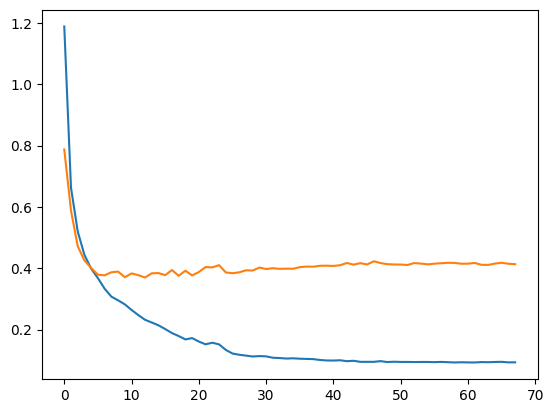

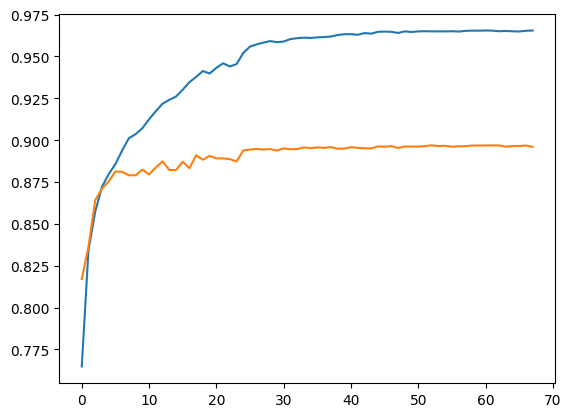

In [11]:
########################################################################################################################
# 7. TRENIRANJE MODELA
########################################################################################################################

best_val_acc = 0.0
epochs_no_improve = 0

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

with open(path_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['epoch', 'loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

print("Početak treniranja...")
for epoch in range(num_epochs):
    # TRENING FAZA
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels).item()
        total_train += labels.numel()

    train_loss = train_loss / len(train_loader.dataset)
    train_acc = correct_train / total_train

    # VALIDACIONA FAZA
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels).item()
            total_val += labels.numel()

    val_loss = val_loss / len(valid_loader.dataset)
    val_acc = correct_val / total_val

    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f} || LR: {current_lr:.8f}")

    with open(path_csv, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([epoch+1, train_loss, train_acc, val_loss, val_acc, current_lr])

    scheduler.step(val_acc)

    # Model Checkpoint i Early Stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), path_model)
        print(" -> Snimljen novi najbolji model!")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stopping_patience:
        print(f"Rano zaustavljanje! Nema poboljšanja {early_stopping_patience} epoha zaredom.")
        break

# SNIMANJE GRAFIKONA
plt.clf()
plt.plot(history['loss'], label='Trening')
plt.plot(history['val_loss'], label='Validacija')
plt.savefig(os.path.join(drive_results_folder, 'training_loss.png'))
plt.show()

plt.clf()
plt.plot(history['accuracy'], label='Trening')
plt.plot(history['val_accuracy'], label='Validacija')
plt.savefig(os.path.join(drive_results_folder, 'training_accuracy.png'))
plt.show()

In [12]:
########################################################################################################################
# 8. EVALUACIJA MODELA
########################################################################################################################

def evaluate_model(model, dataloader, criterion, device):
    model.eval() # Postavljanje modela u režim evaluacije (isključuje dropout i batchnorm trening)
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # Isključivanje računanja gradijenata radi uštede memorije i brzine
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            # Računanje tačnosti po pikselu
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()
            total += labels.numel()

    total_loss = running_loss / len(dataloader.dataset)
    total_acc = correct / total
    return total_loss, total_acc

# 1. Kreiranje Data Loadera za trening skup bez augmentacije
train_dataset_no_aug = VOCDataset(is_validation=False, data_augmentation=False)
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size, shuffle=False, num_workers=2)

# 2. Pokretanje evaluacije
res_train = evaluate_model(model, train_loader_no_aug, criterion, device)
res_test = evaluate_model(model, valid_loader, criterion, device)

print(f"Evaluacija nad trening skupom (Loss, Acc): {res_train}")
print(f"Evaluacija nad test skupom (Loss, Acc): {res_test}")

training_elements = 2330
Evaluacija nad trening skupom (Loss, Acc): (0.07996726487583357, 0.9692024329189579)
Evaluacija nad test skupom (Loss, Acc): (0.41348501907000207, 0.8959652882701946)


Učitavanje najboljeg modela za evaluaciju
Obrada slika (učitavanje, predikcija i snimanje)...
Obrađeno 50 / 583 slika...
Obrađeno 100 / 583 slika...
Obrađeno 150 / 583 slika...
Obrađeno 200 / 583 slika...
Obrađeno 250 / 583 slika...
Obrađeno 300 / 583 slika...
Obrađeno 350 / 583 slika...
Obrađeno 400 / 583 slika...
Obrađeno 450 / 583 slika...
Obrađeno 500 / 583 slika...
Obrađeno 550 / 583 slika...


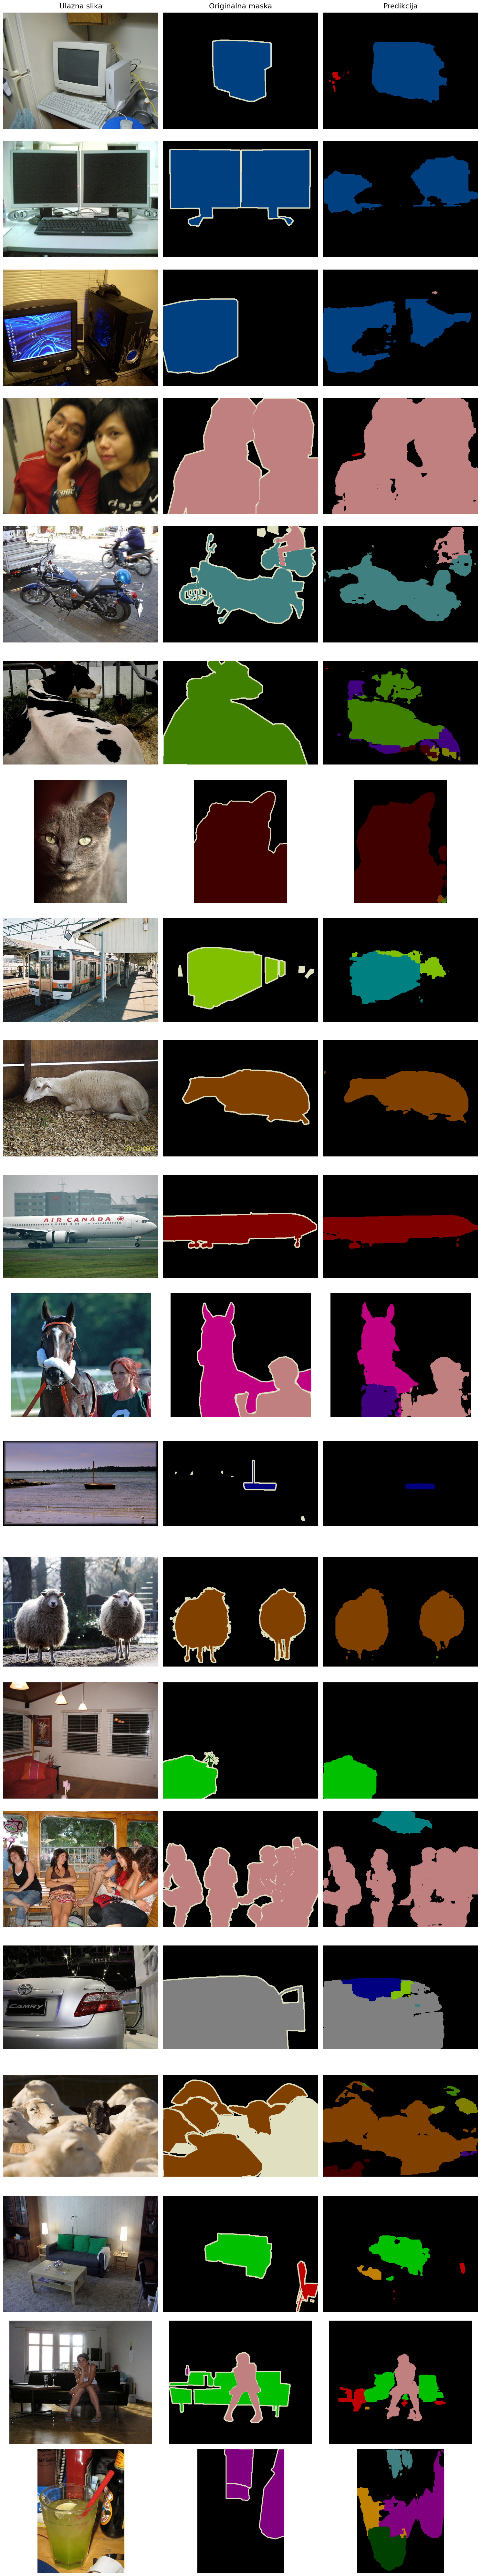

In [13]:
########################################################################################################################
# 9. UČITAVANJE MODELA I GENERISANJE PREDIKCIJA ZA TEST PODATKE
########################################################################################################################

print('Učitavanje najboljeg modela za evaluaciju')
model.load_state_dict(torch.load(path_model))
model.eval()

# PRIPREMA LISTE TEST PODATAKA
test_data = []
cnt = 0
for filename_gt in train_images_gt:
    filename = filename_gt[:-4] + '.jpg'
    if cnt % 5 == 2:
        test_data.append((filename, filename_gt))
    cnt += 1

eval_path = os.path.join(drive_results_folder, "eval")
if not os.path.exists(eval_path):
    os.makedirs(eval_path)

num_display = min(20, len(test_data))
fig, axes = plt.subplots(nrows=num_display, ncols=3, figsize=(15, 4 * num_display))

print('Obrada slika (učitavanje, predikcija i snimanje)...')
for i in range(len(test_data)):
    filename, filename_gt = test_data[i]
    img_path = os.path.join(train_folder, filename)
    img_path_gt = os.path.join(train_folder_gt, filename_gt)
    img_path_pred = os.path.join(eval_path, filename_gt[:-4] + '_.png')

    # Učitavanje originalne slike
    img = cv.imread(img_path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Preprocesiranje za model
    img_resized = cv.resize(img_rgb, (image_size, image_size), interpolation=cv.INTER_LINEAR)
    img_norm = img_resized.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_norm = (img_norm - mean) / std
    img_transposed = np.transpose(img_norm, (2, 0, 1))

    # Konverzija u tenzor i slanje na GPU
    img_tensor = torch.tensor(img_transposed, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)
        # Pronalaženje indeksa najveće verovatnoće duž kanala (dimenzija 1)
        pred_classes = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

    # Skaliranje maske na originalne dimenzije
    img_gt_dims = cv.imread(img_path_gt)
    img_pred_resized = cv.resize(pred_classes.astype(np.uint8), (img_gt_dims.shape[1], img_gt_dims.shape[0]), interpolation=cv.INTER_NEAREST)

    # Kopiranje fajlova i primena palete
    copyfile(img_path, os.path.join(eval_path, filename))
    copyfile(img_path_gt, os.path.join(eval_path, filename_gt))

    pil_image_pred = Image.fromarray(img_pred_resized)
    pil_image_pred.putpalette(palette)
    pil_image_pred.save(img_path_pred, 'PNG')

    # Prikaz u gridu
    if i < num_display:
        pil_img_input = Image.open(img_path)
        pil_image_gt = Image.open(img_path_gt)

        axes[i, 0].imshow(pil_img_input)
        axes[i, 1].imshow(pil_image_gt.convert('RGB'))
        axes[i, 2].imshow(pil_image_pred.convert('RGB'))

        axes[i, 0].axis('off')
        axes[i, 1].axis('off')
        axes[i, 2].axis('off')

        if i == 0:
            axes[i, 0].set_title("Ulazna slika", fontsize=16, pad=10)
            axes[i, 1].set_title("Originalna maska", fontsize=16, pad=10)
            axes[i, 2].set_title("Predikcija", fontsize=16, pad=10)

    if (i + 1) % 50 == 0:
        print(f"Obrađeno {i + 1} / {len(test_data)} slika...")

plt.tight_layout()
plt.show()